For visualisation


In [34]:
import pandas as pd
import os
from pyspark.sql import SparkSession, functions as F
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

spark = SparkSession.builder.appName("NightSpeedResults").getOrCreate()

directory = '/content/drive/MyDrive/mit805/parquet_files_2024_2025'
fig_dir = '/content/drive/MyDrive/mit805/figures'
os.makedirs(fig_dir, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
read_grouped_df = spark.read.parquet(f"{directory}/grouped_df_output_v2")
read_grouped_df.printSchema()

root
 |-- route: string (nullable = true)
 |-- start_zone: long (nullable = true)
 |-- trip_hour: integer (nullable = true)
 |-- trip_day: integer (nullable = true)
 |-- period: string (nullable = true)
 |-- total_trip_distance: double (nullable = true)
 |-- total_trip_duration_seconds: long (nullable = true)
 |-- trip_count: long (nullable = true)
 |-- avg_speed_mph: double (nullable = true)



In [36]:
spark = SparkSession.builder.appName("MapReduceTripData").getOrCreate()

In [37]:

file_sizes = {}
for filename in os.listdir(directory):
    filepath = os.path.join(directory, filename)
    if os.path.isfile(filepath):
        file_size_bytes = os.path.getsize(filepath)
        file_sizes[filename] = file_size_bytes

for filename, size_bytes in file_sizes.items():
    print(f"File: {filename}, Size: {size_bytes} bytes")

File: yellow_tripdata_2024-01.parquet, Size: 32187562 bytes
File: yellow_tripdata_2024-02.parquet, Size: 34162870 bytes
File: yellow_tripdata_2024-03.parquet, Size: 43023668 bytes
File: yellow_tripdata_2024-04.parquet, Size: 42237498 bytes
File: yellow_tripdata_2024-06.parquet, Size: 42687041 bytes
File: yellow_tripdata_2024-05.parquet, Size: 42715455 bytes
File: yellow_tripdata_2024-11.parquet, Size: 42254234 bytes
File: yellow_tripdata_2024-09.parquet, Size: 44142973 bytes
File: yellow_tripdata_2024-10.parquet, Size: 45397721 bytes
File: yellow_tripdata_2024-08.parquet, Size: 34584181 bytes
File: yellow_tripdata_2024-07.parquet, Size: 35822950 bytes
File: yellow_tripdata_2025-03.parquet, Size: 53635960 bytes
File: yellow_tripdata_2025-02.parquet, Size: 43994065 bytes
File: yellow_tripdata_2025-01.parquet, Size: 40103242 bytes
File: yellow_tripdata_2024-12.parquet, Size: 42712073 bytes
File: yellow_tripdata_2025-07.parquet, Size: 47734824 bytes
File: yellow_tripdata_2025-06.parquet, S

In [38]:
read_grouped_df = spark.read.parquet(directory)

print("\nGrouped DataFrame")
read_grouped_df.show(5)


Grouped DataFrame
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+-------------------+-------------------+---------------------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|         started_at|           ended_at|trip_duration_seconds|     avg_speed_mph|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+-------

# **Check which hours are in the data**

In [40]:
# Load the pre-aggregated data which contains 'trip_hour' and 'trip_count'
correct_grouped_df = spark.read.parquet("/content/drive/MyDrive/mit805/parquet_files_2024_2025/grouped_df_output_v2")

# Group and show the trip counts by hour
(correct_grouped_df.groupBy("trip_hour")
    .agg(F.sum("trip_count").alias("trips"))
    .orderBy("trip_hour")
    .show(24))

+---------+-------+
|trip_hour|  trips|
+---------+-------+
|        0|2671339|
|        1|1741900|
|        2|1138797|
|        3| 762337|
|        4| 581475|
|        7|      1|
|        8|      1|
|       11|      1|
|       18|      1|
|       19|     15|
|       20|5088848|
|       21|5211695|
|       22|4866726|
|       23|3806629|
+---------+-------+



# **Roll up to zone and hour**

In [41]:
# Define the night hours based on the dataset's distribution
night_order = [20, 21, 22, 23, 0, 1, 2, 3, 4]

# Correct base directory inside parquet_files_2024_2025
correct_directory = "/content/drive/MyDrive/mit805/parquet_files_2024_2025"

# Loading from the correct folder: grouped_df_output_v2 and rolling it up
zone_hour = (spark.read.parquet(f"{correct_directory}/grouped_df_output_v2")
    .filter(F.col("trip_hour").isin(night_order))
    .groupBy("start_zone", "trip_hour")
    .agg(F.sum("trip_count").alias("trips"),
         F.sum("total_trip_distance").alias("miles"),
         F.sum("total_trip_duration_seconds").alias("seconds"))
    .withColumn("avg_speed_mph", F.col("miles") / F.col("seconds") * 3600))

zone_hour.cache()
zone_hour.count()

2324

# **Speed by hour**

In [42]:
by_hour = (zone_hour.groupBy("trip_hour")
    .agg(F.sum("trips").alias("trips"),
         F.sum("miles").alias("miles"),
         F.sum("seconds").alias("seconds"))
    .withColumn("avg_speed_mph", F.col("miles") / F.col("seconds") * 3600))

# Define the labels mapping to each night hour in night_order
night_labels = ["20:00", "21:00", "22:00", "23:00", "00:00", "01:00", "02:00", "03:00", "04:00"]

by_hour_pd = by_hour.toPandas().set_index("trip_hour").reindex(night_order).reset_index()
by_hour_pd["label"] = night_labels
by_hour_pd[["label", "trips", "avg_speed_mph"]]

,label,trips,avg_speed_mph
0,20:00,5088848,13.009072
1,21:00,5211695,13.353215
2,22:00,4866726,13.736902
3,23:00,3806629,14.943463
4,00:00,2671339,15.608786
5,01:00,1741900,15.207083
6,02:00,1138797,15.248767
7,03:00,762337,16.652821
8,04:00,581475,19.632811


# **Speed by zone, with zone names**

In [43]:
#zone names from the TLC lookup file (265 rows, fine for pandas)
zones_pd = pd.read_csv("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv", keep_default_na=False)
zones = spark.createDataFrame(zones_pd[["LocationID", "Borough", "Zone"]])

#ignoring zones under 1,000 trips and the catch-all zones 264 and 265
by_zone = (zone_hour.groupBy("start_zone")
    .agg(F.sum("trips").alias("trips"),
         F.sum("miles").alias("miles"),
         F.sum("seconds").alias("seconds"))
    .withColumn("avg_speed_mph", F.col("miles") / F.col("seconds") * 3600)
    .filter(F.col("trips") >= 1000)
    .filter(~F.col("start_zone").isin(264, 265))
    .join(F.broadcast(zones), F.col("start_zone") == zones.LocationID, "left"))

by_zone.cache()
print("Slowest zones")
by_zone.orderBy("avg_speed_mph").select("Zone", "Borough", "trips", "avg_speed_mph").show(10, truncate=False)
print("Fastest zones")
by_zone.orderBy(F.desc("avg_speed_mph")).select("Zone", "Borough", "trips", "avg_speed_mph").show(5, truncate=False)

Slowest zones
+-----------------------------+---------+-------+------------------+
|Zone                         |Borough  |trips  |avg_speed_mph     |
+-----------------------------+---------+-------+------------------+
|Greenwich Village North      |Manhattan|450046 |10.281608701040856|
|Penn Station/Madison Sq West |Manhattan|747003 |10.327819460174393|
|West Village                 |Manhattan|1107072|10.337682326310556|
|Union Sq                     |Manhattan|799333 |10.380676250566689|
|Midtown Center               |Manhattan|1046036|10.412650378067093|
|Greenwich Village South      |Manhattan|787577 |10.50121913063746 |
|Central Park                 |Manhattan|192314 |10.529193583950386|
|Meatpacking/West Village West|Manhattan|431051 |10.572553472874036|
|SoHo                         |Manhattan|289668 |10.607790285251397|
|Midtown North                |Manhattan|638029 |10.631572268785371|
+-----------------------------+---------+-------+------------------+
only showing top 10 

In [44]:
overall_speed = by_hour_pd["miles"].sum() / by_hour_pd["seconds"].sum() * 3600
slow_hour = by_hour_pd.loc[by_hour_pd["avg_speed_mph"].idxmin()]
fast_hour = by_hour_pd.loc[by_hour_pd["avg_speed_mph"].idxmax()]

print(f"Trips analysed: {int(by_hour_pd['trips'].sum()):,}")
print(f"Overall night speed: {overall_speed:.1f} mph")
print(f"Slowest hour: {slow_hour['label']} ({slow_hour['avg_speed_mph']:.1f} mph)")
print(f"Fastest hour: {fast_hour['label']} ({fast_hour['avg_speed_mph']:.1f} mph)")

Trips analysed: 25,869,746
Overall night speed: 14.2 mph
Slowest hour: 20:00 (13.0 mph)
Fastest hour: 04:00 (19.6 mph)


# **Figure 1: speed by hour**

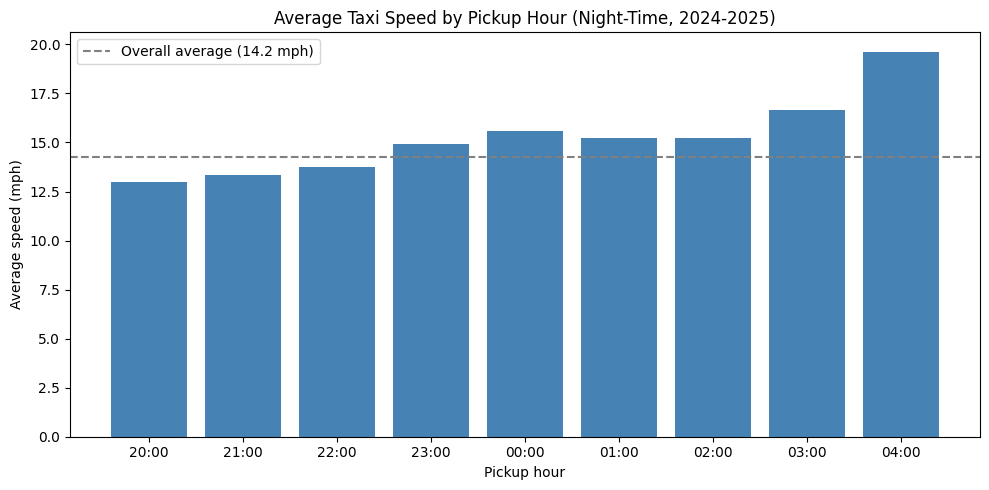

In [45]:
#bars start at zero so differences are not exaggerated
plt.figure(figsize=(10, 5))
plt.bar(by_hour_pd["label"], by_hour_pd["avg_speed_mph"], color="steelblue")
plt.axhline(overall_speed, color="grey", linestyle="--", label=f"Overall average ({overall_speed:.1f} mph)")
plt.title("Average Taxi Speed by Pickup Hour (Night-Time, 2024-2025)")
plt.xlabel("Pickup hour")
plt.ylabel("Average speed (mph)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{fig_dir}/fig1_speed_by_hour.png", dpi=200)
plt.show()

# **Figure 2: slowest zones**

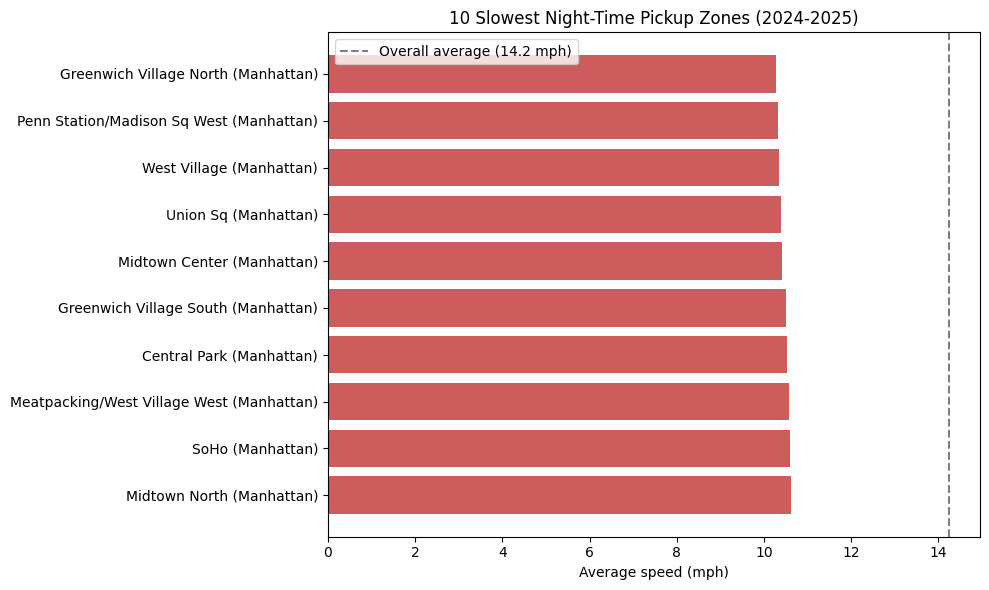

In [46]:
slowest = by_zone.orderBy("avg_speed_mph").limit(10).toPandas()
slowest["label"] = slowest["Zone"] + " (" + slowest["Borough"] + ")"

plt.figure(figsize=(10, 6))
plt.barh(slowest["label"], slowest["avg_speed_mph"], color="indianred")
plt.axvline(overall_speed, color="grey", linestyle="--", label=f"Overall average ({overall_speed:.1f} mph)")
plt.gca().invert_yaxis()
plt.title("10 Slowest Night-Time Pickup Zones (2024-2025)")
plt.xlabel("Average speed (mph)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{fig_dir}/fig2_slowest_zones.png", dpi=200)
plt.show()

# **Figure 3: zone by hour heatmap**

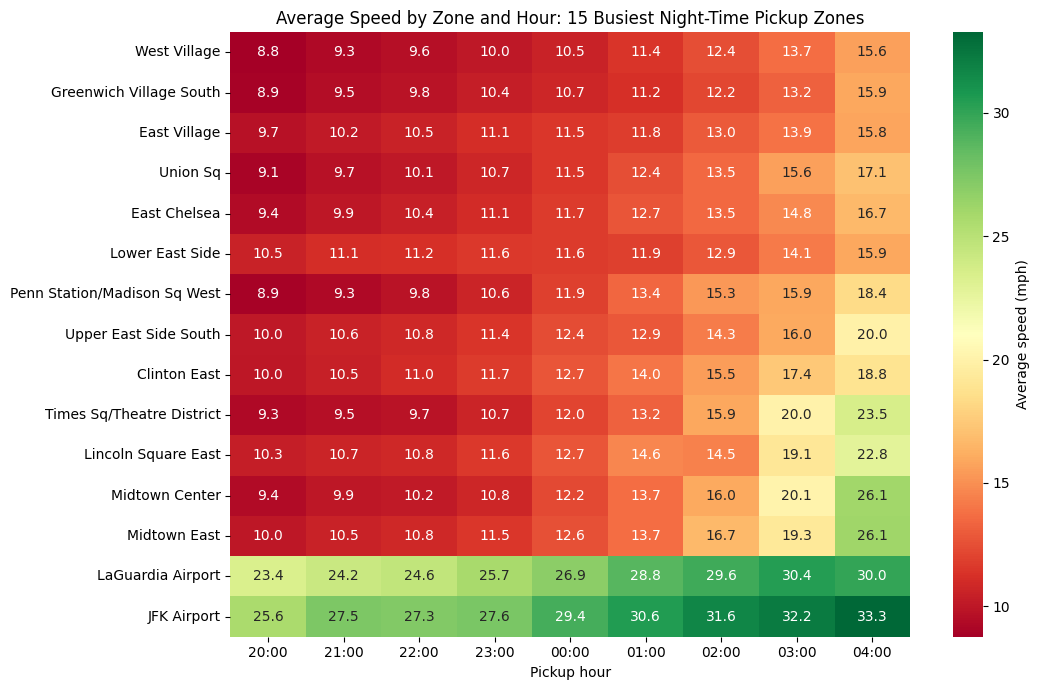

In [47]:
#15 busiest zones, hour cells under 100 trips left blank
top15 = by_zone.orderBy(F.desc("trips")).limit(15).select("start_zone", "Zone")

heat = (zone_hour.join(top15, "start_zone")
    .filter(F.col("trips") >= 100)
    .select("Zone", "trip_hour", "avg_speed_mph")).toPandas()

heat_table = heat.pivot_table(index="Zone", columns="trip_hour", values="avg_speed_mph").reindex(columns=night_order)
heat_table.columns = night_labels
heat_table = heat_table.loc[heat_table.mean(axis=1).sort_values().index]

plt.figure(figsize=(11, 7))
sns.heatmap(heat_table, annot=True, fmt=".1f", cmap="RdYlGn", cbar_kws={"label": "Average speed (mph)"})
plt.title("Average Speed by Zone and Hour: 15 Busiest Night-Time Pickup Zones")
plt.xlabel("Pickup hour")
plt.ylabel("")
plt.tight_layout()
plt.savefig(f"{fig_dir}/fig3_zone_hour_heatmap.png", dpi=200)
plt.show()

# **Figure 4: monthly trend**

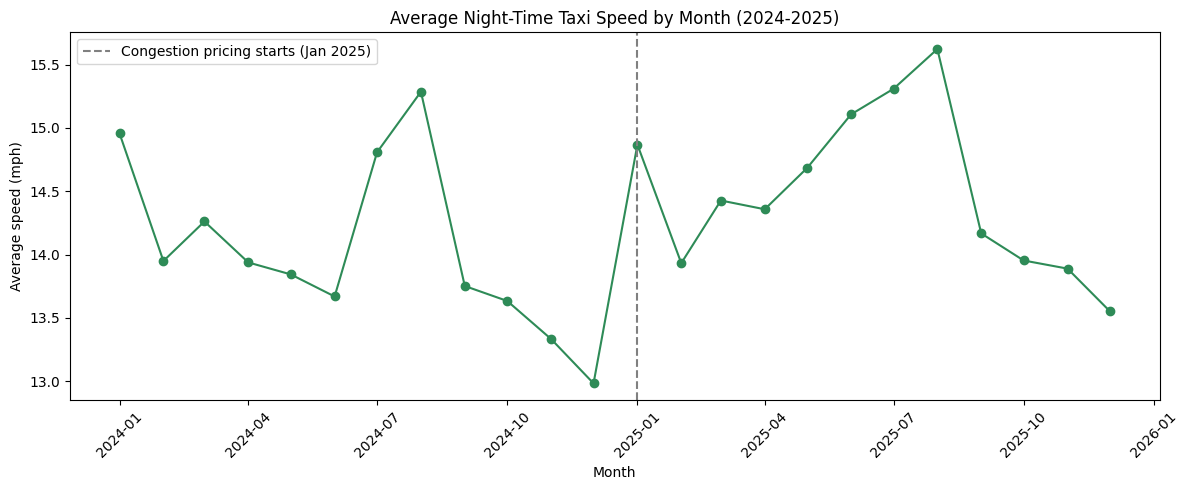

In [49]:
# Group the pre-aggregated dataset by period to get monthly metrics
by_month = (correct_grouped_df.groupBy("period")
    .agg(F.sum("total_trip_distance").alias("miles"),
         F.sum("total_trip_duration_seconds").alias("seconds"))
    .withColumn("avg_speed_mph", F.col("miles") / F.col("seconds") * 3600)
    .orderBy("period")).toPandas()
by_month["month"] = pd.to_datetime(by_month["period"], format="%Y%m")

plt.figure(figsize=(12, 5))
plt.plot(by_month["month"], by_month["avg_speed_mph"], marker="o", color="seagreen")
plt.axvline(pd.Timestamp("2025-01-01"), color="grey", linestyle="--", label="Congestion pricing starts (Jan 2025)")
plt.title("Average Night-Time Taxi Speed by Month (2024-2025)")
plt.xlabel("Month")
plt.ylabel("Average speed (mph)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(f"{fig_dir}/fig4_monthly_speed.png", dpi=200)
plt.show()